In [23]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy
from functools import reduce

from torch import nn
import pickle as pkl
from umap import UMAP

from model import DNN
from run_sim import Config, run_sim, create_data, train_model
from utils import cosine_similarity, get_r_2, vector_angle, flatten_list
from utils import factorize_matrix, compute_hessian

from tqdm import tqdm
from utils import alignment_score, calc_PR, calc_NC1
import matplotlib as mpl
from functools import reduce



In [24]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [25]:
import torch
import torch.nn as nn
import copy

def compute_normalized_sharpness_full_batch(model, X, y, loss_fn, rho=0.05, device='cpu'):
    """
    Computes the normalized sharpness for a single full batch (X, y).

    Args:
        model: Trained PyTorch model.
        X (torch.Tensor): Input tensor of shape (N, ...).
        y (torch.Tensor): Target tensor of shape (N,).
        loss_fn: Loss function, e.g., nn.CrossEntropyLoss().
        rho: Perturbation scale factor (default 0.05).
        device: Device to use ('cpu' or 'cuda').

    Returns:
        float: Normalized sharpness value.
    """
    X, y = X.to(device), y.to(device)
    model = copy.deepcopy(model).to(device)
    model.eval()

    # Compute original loss
    with torch.no_grad():
        outputs, _ = model(X)
        print(y.shape)
        original_loss = loss_fn(outputs, y).item()

    # Perturb weights
    perturbed_model = copy.deepcopy(model)
    for param in perturbed_model.parameters():
        if param.requires_grad:
            eps = rho * (param.abs() + 1.0)
            perturbation = torch.empty_like(param).uniform_(-1, 1) * eps
            param.data.add_(perturbation)

    # Compute perturbed loss
    with torch.no_grad():
        outputs_perturbed, _ = perturbed_model(X)
        perturbed_loss = loss_fn(outputs_perturbed, y).item()

    # Compute normalized sharpness
    normalized_sharpness = (perturbed_loss - original_loss) / (1 + original_loss)
    return normalized_sharpness

def get_AB(X, w1, w2, b, n):
    # Step 1: Compute target matrix
    Y = (X @ w1) @ w2 + np.ones((X.shape[0], 1)) @ b  # (m, c)

    # Step 2: Compute effective Z = X^\dagger Y
    X_dagger = np.linalg.pinv(X)                     # (d, m)
    Z = X_dagger @ Y                                 # (d, c)

    # Step 3: Low-rank SVD factorization
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    n_max = min(n, min(Z.shape))  # Don't take more components than available
    U_n = np.zeros((U.shape[0], n))  # Initialize with zeros
    S_n = np.zeros((n, n))  # Initialize diagonal matrix with zeros
    Vn = np.zeros((n, Vt.shape[1]))  # Initialize with zeros
    
    # Fill available components
    U_n[:, :n_max] = U[:, :n_max]
    S_n[:n_max, :n_max] = np.diag(np.sqrt(S[:n_max]))
    Vn[:n_max, :] = Vt[:n_max, :]

    A = U_n @ S_n                  # (d, n)
    B = S_n @ Vn                   # (n, c)
    return A, B


In [26]:
C = Config()
C.length_corridors = [10]
C.max_move = C.length_corridors[0]//2
C.hidden_size = 21

device = torch.device(f"cuda:{C.gpu_id}" if torch.cuda.is_available() else "cpu")
torch.manual_seed(C.seed)
np.random.seed(C.seed)

X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)

X = torch.tensor(X).to(device)
y = torch.tensor(y).to(device)

X_np = X.cpu().numpy()
y_np = y.cpu().numpy()


In [54]:
L = C.length_corridors[0]
L_start = -L/2; L_end = L/2
A = C.max_move
n_model = 1
Win = np.concatenate([np.arange(1,L+1, 1), np.arange(-A,A+1)])[:,None]
Wout = 1/n_model*np.arange(1,L+1, 1)[None,:]**n_model
b = -1/(n_model+1)*np.arange(1,L+1, 1)[None, :]**(n_model+1)
print('Accuracy of tailored solution: ', ((X_np@Win@Wout+b).argmax(1)==(y_np.argmax(1))).mean())

A,B = get_AB(X_np, Win, Wout, b, C.hidden_size)
W_synthetic = (A@B).T
print('Accuracy of tailored solution: ', ((X_np@A@B).argmax(1)==(y_np.argmax(1))).mean())

Accuracy of tailored solution:  1.0
Accuracy of tailored solution:  1.0


/home/avivra/PycharmProjects/RepresentationShaping/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


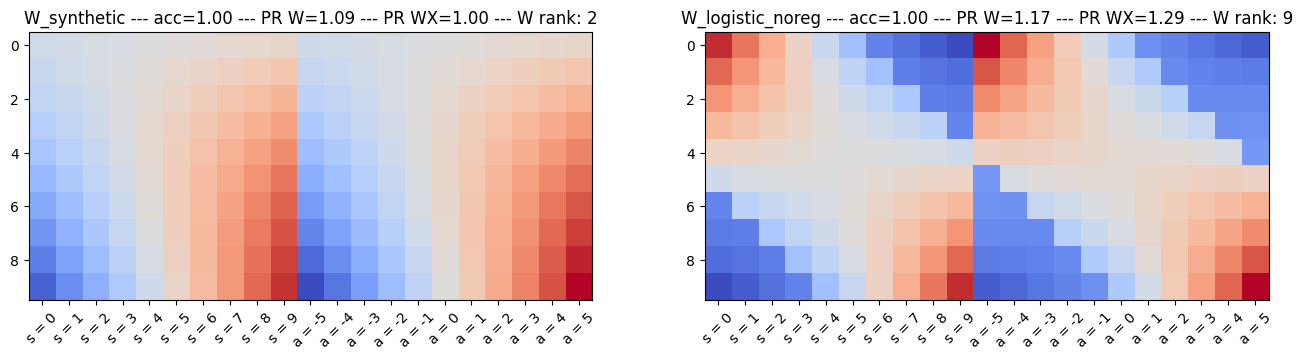

In [56]:
W_dict = {
    'W_synthetic':W_synthetic,
    'W_logistic_noreg':LogisticRegression(multi_class='multinomial', penalty=None, fit_intercept=False, tol=1e-12).fit(X_np, y_np.argmax(1)).coef_,
}
# for k,v in W_dict.items():
#     W_dict[k] = v/v.max()
fig, axs = plt.subplots(1, len(W_dict), figsize=(8*len(W_dict),5))
for ax, (W_name, W) in zip(axs, W_dict.items()):
    # if W_name == 'W_loremote
    #  = W
    ax.imshow(W, cmap='coolwarm')
    lamb = PCA().fit(X_np@W.T).explained_variance_
    PRWX = lamb.sum() ** 2 / (lamb ** 2).sum()
    lamb = PCA().fit(W).explained_variance_
    PR = lamb.sum() ** 2 / (lamb ** 2).sum()
    ax.set_title(f'{W_name} --- acc={accuracy_score((X_np@W.T).argmax(1), y_np.argmax(1)):.2f} --- PR W={PR:.2f} --- PR WX={PRWX:.2f} --- W rank: {np.linalg.matrix_rank(W, tol=np.sqrt(lamb[0])*(1/W.shape[0]))}')
    ax.set_xticks(np.arange(X_np.shape[1]), [f's = {i}' for i in range(loc_y.max()+1)]+[f'a = {i}' for i in range(-C.max_move, C.max_move+1)], rotation=45)
    ax.grid(False)

Computing Hessian for W_synthetic...
Computing Hessian for W_logistic_noreg...


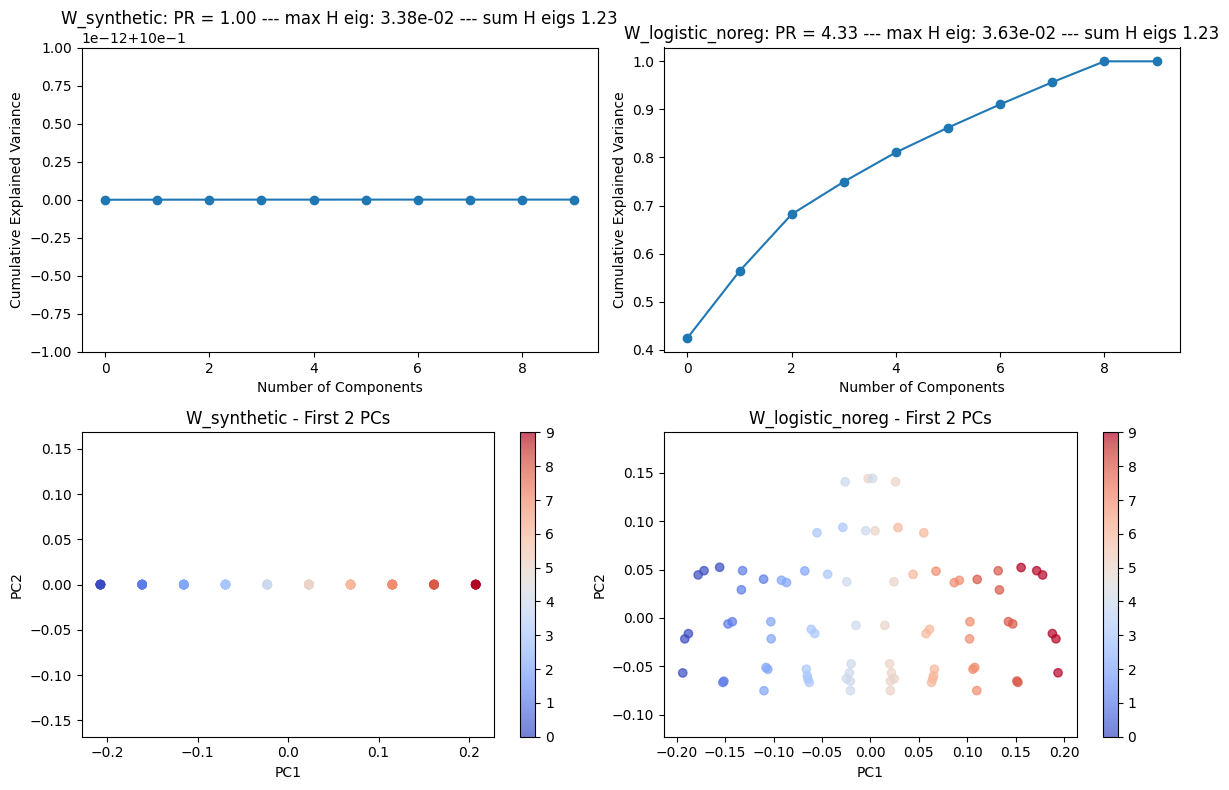

In [57]:
def normalize_W_l(W_l, norm=100):
    theta = torch.concatenate([W.flatten() for W in W_l])
    factor = torch.linalg.norm(theta)/norm
    return [W/factor for W in W_l]

# Create figure with subplots for each W matrix
fig, axs = plt.subplots(2, len(W_dict), figsize=(6*len(W_dict), 8))
axs = axs.T
for i, (W_name, W) in enumerate(W_dict.items()):
    # Factorize matrix and get synthetic hidden states
    # if W_name == 'W_model':
    #     U, S, V = np.linalg.svd(W)
    #     W = U[:,:2]@np.diag(S[:2])@V[:2,:]
    A, B = factorize_matrix(W, N=None)
    print(f"Computing Hessian for {W_name}...")
    W_l = [torch.tensor(w).to(device) for w in [B, A]]
    W_l = normalize_W_l(W_l, 1)
    B, A = [w.cpu().numpy() for w in W_l]
    H = compute_hessian([torch.tensor(w).to(device) for w in [B, A]], X, y)
    eigvals = abs(np.linalg.eigvals(H))

    h_synthetic = X_np @ B.T
    
    # Fit PCA
    pca = PCA().fit(h_synthetic)
    X_reduced = pca.transform(h_synthetic)
    
    # Plot explained variance ratio
    axs[i,0].plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    PR = pca.explained_variance_.sum()**2/(pca.explained_variance_**2).sum()
    axs[i,0].set_xlabel('Number of Components')
    axs[i,0].set_ylabel('Cumulative Explained Variance')
    axs[i,0].set_title(f'{W_name}: PR = {PR:.2f} --- max H eig: {eigvals.max():.2e} --- sum H eigs {eigvals.sum():.2f}')
    
    # Plot first two PCs colored by location
    s = axs[i,1].scatter(X_reduced[:, 0], X_reduced[:, 1], c=loc_y, 
                        cmap='coolwarm', alpha=0.7)
    axs[i,1].set_xlabel('PC1')
    axs[i,1].set_ylabel('PC2')
    axs[i,1].set_title(f'{W_name} - First 2 PCs')
    fig.colorbar(s, ax=axs[i,1])
    axs[i,1].axis('equal')

plt.tight_layout()
plt.show()

In [75]:



for W_name, W in W_dict.items():
    A, B = factorize_matrix(W, N=C.hidden_size)

    W_l = [torch.tensor(w).to(device) for w in [B, A]]
    # W_l = normalize_W_l(W_l, 1)
    B, A = [w.cpu().numpy() for w in W_l]
    
    model = DNN(input_size + n_actions, C.hidden_size, output_size, 1, C.fixed_output, C.linear_net, C.G, C.bias).to(device)
    for param, w in zip(model.parameters(), [B, A]):
        param.data = torch.tensor(w).to(device)
 
    sharpness = compute_normalized_sharpness_full_batch(model, X, y, C.loss_fn, rho=0.05, device=device)
    print(f"Sharpness for {W_name}: {sharpness:.4e}")

torch.Size([80, 10])
Sharpness for W_synthetic: -1.2023e-02
torch.Size([80, 10])
Sharpness for W_logistic_noreg: -1.9166e-02


In [61]:
def normalize_W_l(W_l, norm=100):
    theta = torch.concatenate([W.flatten() for W in W_l])
    factor = torch.linalg.norm(theta)/norm
    return [W/factor for W in W_l]

norm_l = np.logspace(-1, 1, 100)
eig_max_l = []
eig_sum_l = []
for i, (W_name, W) in enumerate(W_dict.items()):
    # Factorize matrix and get synthetic hidden states
    # if W_name == 'W_model':
    #     U, S, V = np.linalg.svd(W)
    #     W = U[:,:2]@np.diag(S[:2])@V[:2,:]
    A, B = factorize_matrix(W, N=None)
    print(f"Computing Hessian for {W_name}...")
    W_l = [torch.tensor(w).to(device) for w in [B, A]]
    max_l = []
    sum_l = []
    for norm in tqdm(norm_l):
        W_l = normalize_W_l(W_l, norm)
        B, A = [w.cpu().numpy() for w in W_l]
        H = compute_hessian([torch.tensor(w).to(device) for w in [B, A]], X, y)
        eigvals = abs(np.linalg.eigvals(H))
        max_l.append(eigvals.max())
        sum_l.append(eigvals.sum())

    eig_max_l.append(max_l)
    eig_sum_l.append(sum_l)



Computing Hessian for W_synthetic...


100%|██████████| 100/100 [01:06<00:00,  1.50it/s]


Computing Hessian for W_logistic_noreg...


100%|██████████| 100/100 [01:06<00:00,  1.50it/s]


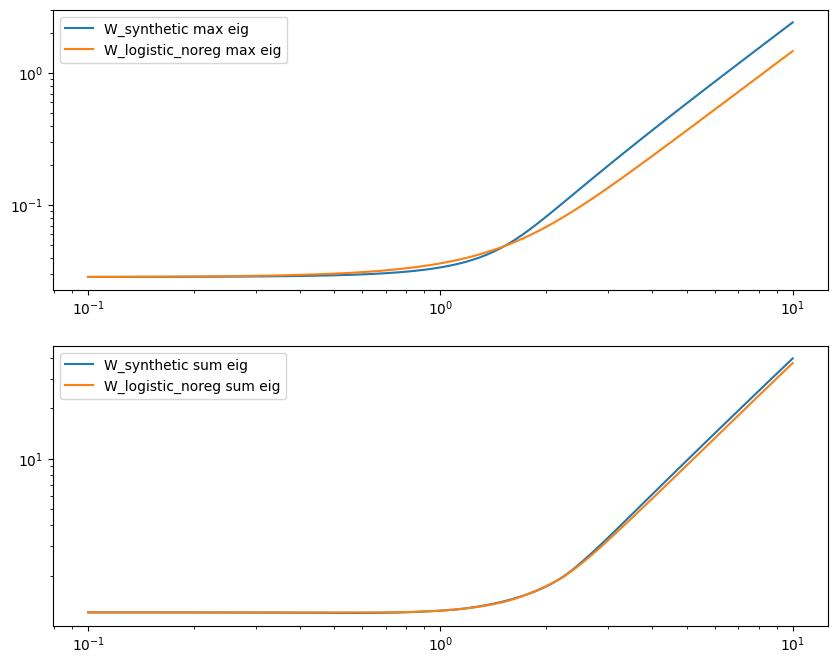

In [62]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

[ax1.plot(norm_l, eig_max_l[i], label=f'{W_name} max eig') for i, W_name in enumerate(W_dict.keys())]
[ax2.plot(norm_l, eig_sum_l[i], label=f'{W_name} sum eig') for i, W_name in enumerate(W_dict.keys())]
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xscale('log')
ax2.set_xscale('log')
ax1.legend()
ax2.legend()
plt.show()
